### Introdução

O conjunto de dados Global Data on Sustainable Energy, disponibilizado no Kaggle, reúne informações detalhadas sobre consumo energético, fontes renováveis, emissões de CO₂, acesso à eletricidade e indicadores econômicos para países de todo o mundo. Esses dados são fundamentais para o monitoramento do progresso em sustentabilidade energética, planejamento de políticas públicas e análise comparativa entre diferentes regiões e faixas de renda.

A natureza quantitativa dessas informações permite a aplicação de métodos estatísticos adequados para dados de contagem, com destaque para os Modelos Lineares Generalizados (GLM), que possibilitam investigar fatores associados ao número de projetos ou eventos relacionados à energia renovável implementados em cada país.

### O Banco de Dados

O banco de dados contém registros anuais agregados por país, contemplando variáveis como população, consumo total de energia, consumo de energia renovável, emissões de CO₂, acesso à eletricidade, intensidade energética e PIB. Também inclui informações categóricas sobre região geográfica e faixa de renda, permitindo comparações espaciais e socioeconômicas.

Essa estrutura possibilita a **análise de contagens de eventos relacionados à energia, como o número de projetos de energia renovável implementados por país/ano**, bem como a investigação de padrões de consumo e emissão de carbono em diferentes contextos socioeconômicos e geográficos.

### Modelagem Estatística (GLM)

A variável resposta principal — número de projetos de energia renovável implementados — é caracterizada como dado de contagem, assumindo valores inteiros não negativos. Nesse contexto, a análise é conduzida por meio de Modelos Lineares Generalizados (GLM), permitindo modelar a relação entre a variável resposta e um conjunto de covariáveis explicativas, como população, consumo energético, emissões de CO₂, acesso à eletricidade, PIB, região e faixa de renda.

Inicialmente, pode-se empregar a distribuição Poisson, adequada para modelagem de contagens sob a suposição de igualdade entre média e variância. Contudo, devido à heterogeneidade entre países e à variabilidade observada nos dados de energia, é comum a ocorrência de sobredispersão, tornando a Binomial Negativa uma alternativa mais apropriada. Essas abordagens possibilitam a identificação de fatores associados à implementação de projetos de energia renovável e a avaliação de diferenças entre países e regiões

In [163]:
import pandas as pd

df= pd.read_csv(
    "global-data-on-sustainable-energy (1).csv",
    sep=",",
    encoding="latin1",
    low_memory=False
)


In [ ]:
import numpy as np

# Renomear colunas (português, mas fiel ao original)
df = df.rename(columns={
    "Access to electricity (% of population)": "pct_acesso_eletricidade",
    "Primary energy consumption per capita (kWh/person)": "consumo_energia_primaria_kwh_per_capita",
    "Renewables (% equivalent primary energy)": "pct_energia_renovaveis_primaria",
    "Value_co2_emissions_kt_by_country": "co2_emissoes_tm_per_capita",
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": "intensidade_energia_mj_por_pib_ppp", 
    "Renewable-electricity-generating-capacity-per-capita": "capacidade_eletrica_renovavel_per_capita", #per_capita ou por_pessoa é mesma coisa
    "gdp_per_capita": "pib_per_capita",
    "Density\\n(P/Km2)": "densidade_populacional",
    "Access to clean fuels for cooking": "acesso_combustiveis_limpos_para_conzinhar",
    "Financial flows to developing countries (US $)": "fluxo_financeiro_energia_limpa",
    "Electricity from nuclear (TWh)" : "Eletricidade_energia_nuclear",
    "Electricity from fossil fuels (TWh)": "Eletricidade_energia_combustiveis_fosseis",
    "Electricity from renewables (TWh)": "Eletricidade_energia_fontes_renovaveis" 
})

# Seleção de variáveis
cols = [
    "pib_per_capita",
    "consumo_energia_primaria_kwh_per_capita",
   # "pct_energia_renovaveis_primaria",
    "co2_emissoes_tm_per_capita",
    "pct_acesso_eletricidade",
    "intensidade_energia_mj_por_pib_ppp",
    #"capacidade_eletrica_renovavel_per_capita",
    "densidade_populacional",
    "acesso_combustiveis_limpos_para_conzinhar",
   # "fluxo_financeiro_energia_limpa",
    #"Eletricidade_energia_nuclear",
    #"Eletricidade_energia_combustiveis_fosseis",
    #"Eletricidade_energia_fontes_renovaveis" 
]

df['densidade_populacional'] = df['densidade_populacional'].str.replace(',', '').astype(float)

# Conversão de tipos
df_energy_filtrado = df[cols].copy()
df_energy_filtrado = df_energy_filtrado.astype({
    "pib_per_capita": float,
    "consumo_energia_primaria_kwh_per_capita": float,
  #  "pct_energia_renovaveis_primaria": float,
    "co2_emissoes_tm_per_capita": float,
    "pct_acesso_eletricidade": float,
    "intensidade_energia_mj_por_pib_ppp": float,
  #  "capacidade_eletrica_renovavel_per_capita": float,
     "acesso_combustiveis_limpos_para_conzinhar" : float,
  #  "fluxo_financeiro_energia_limpa" : float,
    "densidade_populacional": float
  #  "Eletricidade_energia_nuclear" : float,
  #  "Eletricidade_energia_combustiveis_fosseis" : float,
  #  "Eletricidade_energia_fontes_renovaveis"  : float
})

#print(df.columns.tolist())

# Remover outros NA
df_energy_filtrado = df_energy_filtrado.dropna()
df_energy_filtrado.head()



,pib_per_capita,consumo_energia_primaria_kwh_per_capita,co2_emissoes_tm_per_capita,pct_acesso_eletricidade,intensidade_energia_mj_por_pib_ppp,densidade_populacional,acesso_combustiveis_limpos_para_conzinhar
2,179.426579,210.86215,1029.999971,9.409158,1.40,60.0,8.20
3,190.683814,229.96822,1220.000029,14.738506,1.40,60.0,9.50
4,211.382074,204.23125,1029.999971,20.064968,1.20,60.0,10.90
5,242.031313,252.06912,1549.999952,25.390894,1.41,60.0,12.20
6,263.733602,304.42090,1759.999990,30.718690,1.50,60.0,13.85


A partir do conjunto de dados **Global Data on Sustainable Energy (2000–2020)**, foram selecionadas as variáveis utilizadas na modelagem da **intensidade energética**. Cada variável é classificada quanto ao tipo de dado, natureza e sua relevância para análises baseadas em **Modelos Lineares Generalizados (GLM)**. Essas informações são importantes para compreender a estrutura das variáveis consideradas no modelo e sua relação com a eficiência energética dos países.

| Variável                                      | Tipo de dado | Natureza     | Característica                                                                                                                                                                                                            |
| --------------------------------------------- | ------------ | ------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **intensidade_energia_mj_por_pib_ppp**        | Contínua     | Quantitativa | Quantidade de energia (em megajoules) utilizada para gerar 1 dólar de riqueza ajustado pela paridade do poder de compra; utilizada como **variável resposta**, representando o nível de eficiência energética de um país. |
| **acesso_combustiveis_limpos_para_conzinhar** | Contínua     | Quantitativa | Percentual da população com acesso a combustíveis limpos e tecnologias adequadas para cozinhar; indicador do nível de desenvolvimento energético doméstico e da transição para fontes menos poluentes.                    |
| **pct_acesso_eletricidade**                   | Contínua     | Quantitativa | Percentual da população com acesso à eletricidade; indicador de cobertura energética nacional e desenvolvimento da infraestrutura elétrica.                                                                               |
| **pib_per_capita**                            | Contínua     | Quantitativa | Produto Interno Bruto per capita do país (em dólares); representa o nível médio de desenvolvimento econômico e a capacidade produtiva da economia.                                                                        |
| **consumo_energia_primaria_kwh_per_capita**   | Contínua     | Quantitativa | Consumo total de energia primária por habitante (em kWh); reflete a intensidade do uso de energia nas atividades econômicas e sociais.                                                                                    |
| **co2_emissoes_tm_per_capita**                | Contínua     | Quantitativa | Emissões de dióxido de carbono por habitante (em toneladas métricas); indicador do impacto ambiental associado ao consumo energético.                                                                                     |
| **densidade_populacional**                    | Contínua     | Quantitativa | Número de habitantes por km²; variável associada ao padrão de ocupação territorial, podendo influenciar padrões de consumo energético e eficiência no uso de recursos.                                                    |




### Importância das Medidas Descritivas

As medidas descritivas são utilizadas para caracterizar a estrutura das variáveis do estudo. Variáveis numéricas, como população, consumo total de energia, consumo de energia renovável, emissões de CO₂ e PIB, são descritas por medidas de tendência central, dispersão e amplitude, permitindo resumir sua distribuição entre os países.

Variáveis categóricas, como região geográfica e faixa de renda, são descritas por meio de frequências absolutas e relativas, possibilitando a compreensão da distribuição das categorias. Essas descrições fornecem uma visão inicial dos padrões de implementação de projetos de energia renovável e permitem identificar possíveis agrupamentos ou desigualdades entre países e regiões.

In [186]:
# Estatísticas descritivas básicas
tabela_descritiva = df_energy_filtrado[cols].describe().round(2)

# Aplicando estilo
tabela_descritiva.style.format("{:.2f}") \
                       .set_caption("Estatísticas Descritivas com Skewness e Kurtosis") 


,pib_per_capita,consumo_energia_primaria_kwh_per_capita,co2_emissoes_tm_per_capita,pct_acesso_eletricidade,intensidade_energia_mj_por_pib_ppp,densidade_populacional,acesso_combustiveis_limpos_para_conzinhar
count,3022.00,3022.00,3022.00,3022.00,3022.00,3022.00,3022.00
mean,12285.06,26003.80,168770.50,77.43,5.37,216.71,62.47
std,18340.29,36666.92,797881.82,31.10,3.45,693.25,39.04
min,111.93,0.00,10.00,1.25,1.03,2.00,0.00
25%,1254.57,2856.27,2190.00,56.12,3.30,30.00,22.42
50%,4170.90,12074.37,10880.00,97.42,4.40,83.00,81.60
75%,14295.46,32269.48,64757.50,100.00,6.06,203.00,100.00
max,123514.20,262585.70,10707219.73,100.00,28.20,8358.00,100.00


### Entendo a distribuição dos dados via Pair plot

O pair plot é uma ferramenta gráfica que permite visualizar a distribuição de variáveis numéricas e as relações entre elas. Ele possibilita observar a dispersão dos dados, a presença de valores atípicos e possíveis padrões de associação entre as variáveis.

No contexto dos dados analisados, pode ser utilizado para explorar as variáveis, fornecendo insights sobre variação, tendência e possíveis relações estruturais.

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


scaler = StandardScaler()
df_energy_filtrado[cols] = scaler.fit_transform(df_energy_filtrado[cols])

sns.pairplot(df_energy_filtrado, # Variáveis que queremos no pairplot
vars = cols,
    corner=True,
    height=3.5   # aumenta tamanho de cada gráfico
    )

### Relações lineares entre variáveis numéricas
 A matriz de correlação de Spearman entre as variáveis numéricas do dataset. O objetivo é identificar relações lineares fortes que possam informar próximas etapas (e.g., seleção de variáveis, multicolinearidade, ou insights de causa/efeito possível).

Pontos importantes:
- O coeficiente de Pearson varia de -1 a 1; 1 indica correlação positiva perfeita, -1 correlação negativa perfeita, e 0 nenhuma correlação linear.
- Correlação não implica causalidade: use estes resultados apenas como sinalizadores.
- Atenção a colinearidade: variáveis fortemente correlacionadas podem distorcer modelos que supõem independência entre variáveis (e.g., regressão).

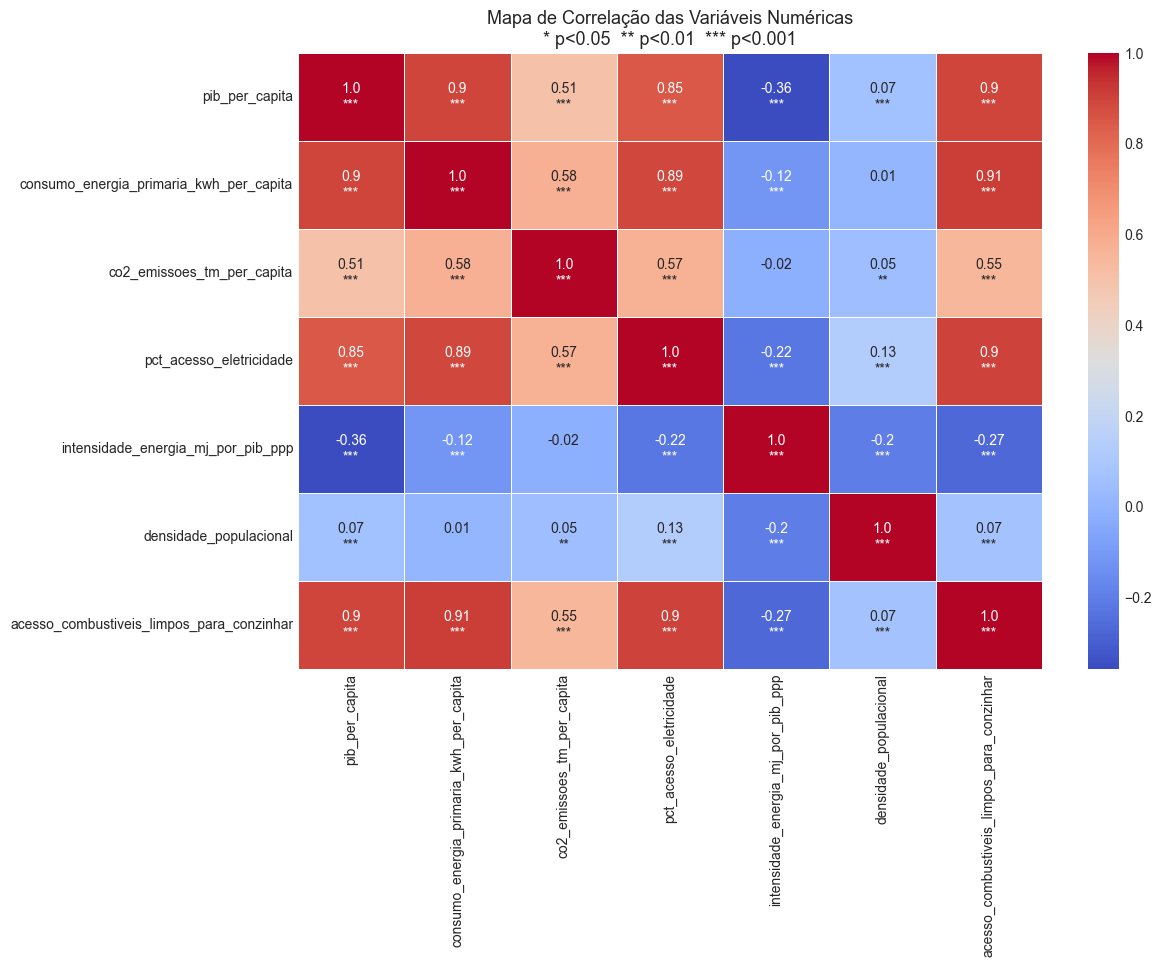

In [175]:
from scipy.stats import spearmanr
import numpy as np

# Calcula correlação e p-valores
corr = df_energy_filtrado.corr(numeric_only=True, method="spearman")
df_num = df_energy_filtrado.select_dtypes(include="number")
pval = pd.DataFrame(
    spearmanr(df_num, nan_policy="omit").pvalue,
    columns=corr.columns, index=corr.index
)

# Cria anotações com asteriscos
def significancia(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

annot = corr.round(2).astype(str) + "\n" + pval.map(significancia)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=annot, cmap='coolwarm', fmt='', linewidths=0.5)
plt.title("Mapa de Correlação das Variáveis Numéricas\n* p<0.05  ** p<0.01  *** p<0.001", fontsize=13)
plt.show()

Diante das variáveis selecionadas, observa-se uma forte relação entre o **Produto Interno Bruto (PIB) per capita**, o **consumo de energia primária por habitante**, o **percentual da população com acesso à eletricidade** e o **percentual da população com acesso a combustíveis limpos para cozinhar**, uma vez que essas variáveis apresentam elevada correlação entre si.

Considerando essa alta correlação, optou-se por analisar o **Fator de Inflação da Variância (VIF)** do modelo, a fim de verificar se esse indício de **multicolinearidade** se confirma. Essa análise é importante para evitar possíveis problemas ou distorções nas estimativas dos parâmetros do modelo.


In [165]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

colunas_x = cols
X = df_energy_filtrado[colunas_x]
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variável"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) 
                 for i in range(X.shape[1])]

print(vif_df.sort_values("VIF", ascending=False))


                                    Variável        VIF
0                                      const  16.123320
7  acesso_combustiveis_limpos_para_conzinhar   4.846732
4                    pct_acesso_eletricidade   4.265886
2    consumo_energia_primaria_kwh_per_capita   3.077760
1                             pib_per_capita   2.504731
5         intensidade_energia_mj_por_pib_ppp   1.407141
6                     densidade_populacional   1.169316
3                 co2_emissoes_tm_per_capita   1.038134


Aparentemente, apenas o **percentual de acesso a combustíveis limpos para cozinhar** e o **percentual de acesso à eletricidade** se aproximaram do limite considerado crítico para o **Fator de Inflação da Variância (VIF)**. Contudo, de forma criteriosa, optou-se por prosseguir com a análise **sem a exclusão dessas variáveis**, uma vez que os valores ainda não ultrapassaram o limite estabelecido para caracterizar multicolinearidade problemática no modelo.


In [176]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

df_energy_filtrado = df_energy_filtrado.reset_index(drop=True)
formula="""
    intensidade_energia_mj_por_pib_ppp ~
    acesso_combustiveis_limpos_para_conzinhar +
                  pct_acesso_eletricidade +
                  pib_per_capita +
                  consumo_energia_primaria_kwh_per_capita +
                  co2_emissoes_tm_per_capita   +
                  densidade_populacional  
    """
# Exemplo de modelo GLM Gamma
modelo = smf.glm(
    formula,
    data=df_energy_filtrado,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

# Resumo do modelo
modelo.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                         Generalized Linear Model Regression Results                          
==============================================================================================
Dep. Variable:     intensidade_energia_mj_por_pib_ppp   No. Observations:                 3024
Model:                                            GLM   Df Residuals:                     3017
Model Family:                                   Gamma   Df Model:                            6
Link Function:                                    Log   Scale:                         0.23732
Method:                                          IRLS   Log-Likelihood:                -6429.9
Date:                                seg, 09 mar 2026   Deviance:                       527.84
Time:                                        11:02:27   Pearson chi2:                     716.
No. Iterations:                                    21   Pseudo R-squ. (CS):             0.3863
Covariance Type:                            nonrobust                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     2.1369      0.026     82.954      0.000       2.086       2.187
acesso_combustiveis_limpos_para_conzinhar     0.0002      0.000      0.356      0.722      -0.001       0.001
pct_acesso_eletricidade                      -0.0076      0.001    -13.294      0.000      -0.009      -0.006
pib_per_capita                             -1.65e-05   7.13e-07    -23.132      0.000   -1.79e-05   -1.51e-05
consumo_energia_primaria_kwh_per_capita    1.147e-05   3.74e-07     30.628      0.000    1.07e-05    1.22e-05
co2_emissoes_tm_per_capita                  6.99e-08   1.13e-08      6.202      0.000    4.78e-08     9.2e-08
densidade_populacional                       -0.0002   1.35e-05    -13.531      0.000      -0.000      -0.000
=============================================================================================================
"""

<!-- - **Predito vs Observado** Observa-se que a maioria dos pontos está concentrada em valores baixos, indicando que o modelo consegue capturar bem os países com menor intensidade energética. Alguns pontos com valores altos estão acima da linha de 45°, sugerindo que o modelo tende a subestimar a intensidade energética em países com valores muito elevados.

- **Resíduos de Pearson vs Valores Ajustados** Há uma dispersão relativamente homogênea dos resíduos ao longo dos valores ajustados, o que é esperado em modelos Gamma. Alguns resíduos estão próximos de ±2, confirmando a presença de observações com intensidade energética inesperadamente alta em relação ao que o modelo prevê.

- **Histograma dos Resíduos Desviance** A distribuição é ligeiramente assimétrica à direita, sugerindo a presença de valores extremos — países com intensidade energética muito elevada. A maioria dos resíduos está concentrada dentro de ±2 desvios, mas as caudas longas reforçam a necessidade de atenção às observações influentes identificadas anteriormente.

- **QQ-Plot dos Resíduos Desviance** A parte central segue aproximadamente a linha teórica, indicando um ajuste razoável do modelo. Nas extremidades, no entanto, há desvios, indicando que os resíduos não seguem perfeitamente a distribuição esperada. Isso é comum em modelos Gamma quando há observações com valores muito discrepantes, como os países identificados na análise de influência. -->

### serão usadas três métricas:

* Resíduo studentizado/padronizado — mede o quão mal o modelo prevê aquela observação. Um valor grande indica que o ponto é um outlier na variável resposta (Y).
  
* Leverage (alavancagem) — mede o quão "extrema" é a observação em termos das variáveis preditoras (X). Um ponto com leverage alto fica longe do centro dos dados, tendo potencial para influenciar o modelo.
  
* Distância de Cook — combina os dois anteriores. Mede o impacto real daquela observação nos coeficientes estimados. É a métrica mais importante para identificar influênci

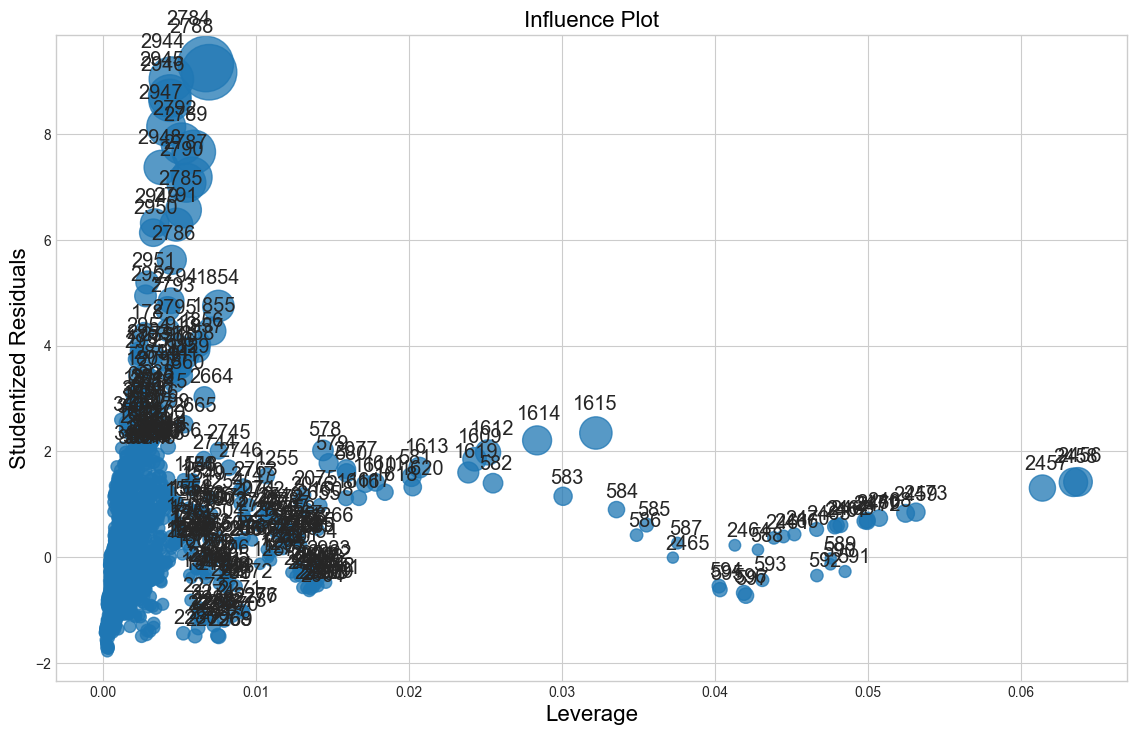

In [177]:

fig, ax = plt.subplots(figsize = (12, 8))
infl = modelo.get_influence(observed=True)
fig = infl.plot_influence(size = 40, ax = ax)
fig.tight_layout(pad=3.0)


Percebemos que há uma parcela de observações com **leverage** (alavancagem), ou seja, pontos de alavancagem relativamente altos. Além disso, observa-se uma grande concentração de valores entre 0 e 0,10, acompanhada de resíduos studentizados muito elevados. Isso já é um indício de que temos diversas observações que podem estar influenciando excessivamente o ajuste do modelo, prejudicando sua estabilidade e qualidade inferencial.

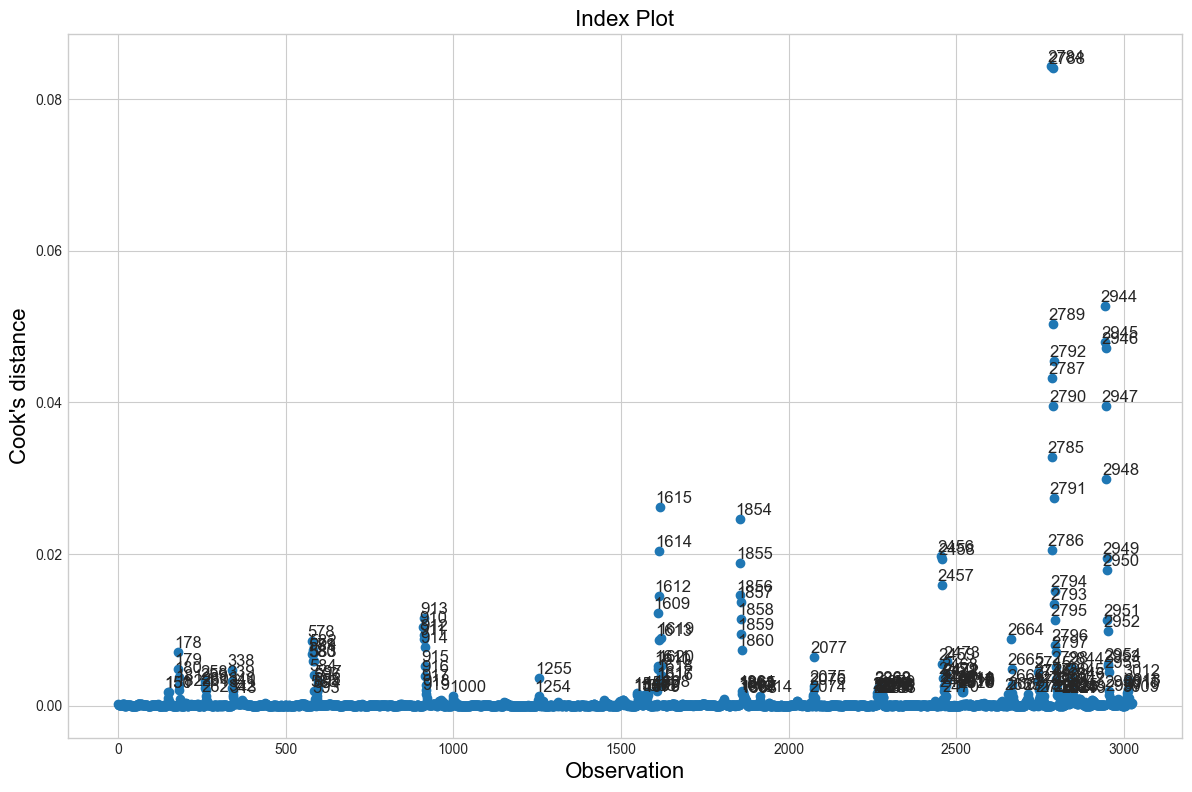

In [178]:
fig = infl.plot_index(y_var="cooks", threshold=2 * infl.cooks_distance[0].mean())
fig.set_size_inches(12, 8)
fig.tight_layout(pad=1.0)

Com o mesmo propósito de identificar observações excessivamente problemáticas, optou-se pela visualização da Distância de Cook. Por meio desse gráfico, é possível identificar claramente dois clusters de observações influentes que impactam de forma considerável a estimação dos parâmetros do modelo. Com base nessa análise, foram removidas apenas as observações que apresentaram simultaneamente uma Distância de Cook elevada e resíduos studentizados altos, por serem as que de fato comprometem a qualidade do ajuste.

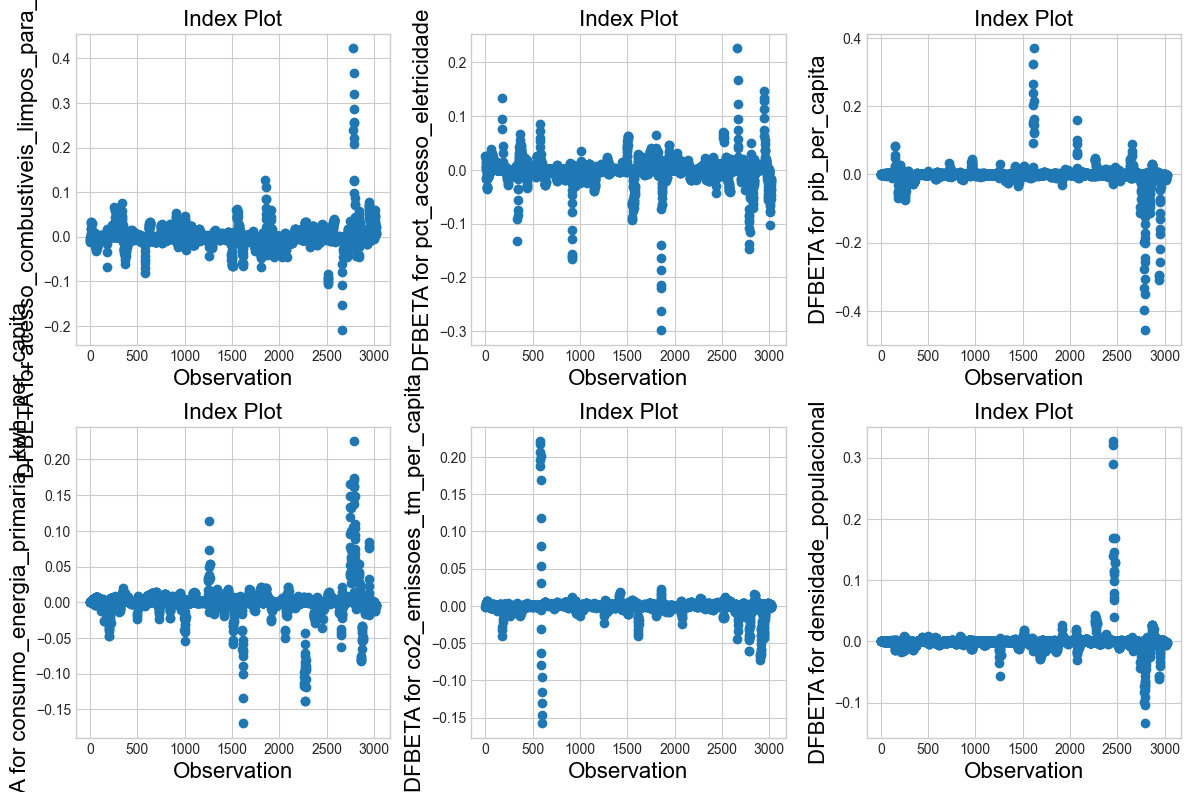

In [ ]:
a = [1, 2, 3, 4, 5,6]
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
axes_flat = axes.flatten()  # transforma em [ax0, ax1, ax2, ax3, ax4, ax5]
for i, ax in zip(a, axes_flat):
    infl.plot_index(y_var="dfbeta", idx=i, threshold=0.5, ax=ax)  # passa UM subplot

# Apaga o subplot vazio (posição 5, já que só tem 5 gráficos)
#axes_flat[-1].set_visible(False)

fig.tight_layout(pad=1.0)
plt.show()

In [183]:
# Remover e reajustar
df_energy_filtrado = df_energy_filtrado.drop(index=[2784, 2788])

modelo = smf.glm(
    formula,
    data=df_energy_filtrado,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Generalized Linear Model Regression Results                          
==============================================================================================
Dep. Variable:     intensidade_energia_mj_por_pib_ppp   No. Observations:                 3022
Model:                                            GLM   Df Residuals:                     3015
Model Family:                                   Gamma   Df Model:                            6
Link Function:                                    Log   Scale:                         0.22633
Method:                                          IRLS   Log-Likelihood:                -6377.4
Date:                                seg, 09 mar 2026   Deviance:                       516.60
Time:                                        11:05:01   Pearson chi2:                     682.
No. Iterations:                                    21   Pseudo R-squ. (CS):             0.4000
Covariance Type:                            nonrobust                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                     2.1367      0.025     84.934      0.000       2.087       2.186
acesso_combustiveis_limpos_para_conzinhar   8.73e-06      0.000      0.018      0.986      -0.001       0.001
pct_acesso_eletricidade                      -0.0075      0.001    -13.488      0.000      -0.009      -0.006
pib_per_capita                            -1.624e-05   6.97e-07    -23.298      0.000   -1.76e-05   -1.49e-05
consumo_energia_primaria_kwh_per_capita    1.142e-05   3.66e-07     31.241      0.000    1.07e-05    1.21e-05
co2_emissoes_tm_per_capita                 7.048e-08    1.1e-08      6.403      0.000    4.89e-08    9.21e-08
densidade_populacional                       -0.0002   1.32e-05    -13.760      0.000      -0.000      -0.000
=============================================================================================================
"""

Tendo em vista a significância da variávels, optamos não por removê-las da modelagem e, com isso, prosseguimos com as interpretações dos coeficientes do modelo gamma.

In [184]:
from matplotlib.pylab import exp #ou
np.exp(modelo.params). round(6)

Intercept                                    8.471233
acesso_combustiveis_limpos_para_conzinhar    1.000009
pct_acesso_eletricidade                      0.992485
pib_per_capita                               0.999984
consumo_energia_primaria_kwh_per_capita      1.000011
co2_emissoes_tm_per_capita                   1.000000
densidade_populacional                       0.999818
dtype: float64

In [185]:
#logit.params
exp(modelo.conf_int(alpha=0.05)).round(6)


,0,1
Intercept,8.063677,8.899388
acesso_combustiveis_limpos_para_conzinhar,0.999053,1.000966
pct_acesso_eletricidade,0.991398,0.993574
pib_per_capita,0.999982,0.999985
consumo_energia_primaria_kwh_per_capita,1.000011,1.000012
co2_emissoes_tm_per_capita,1.000000,1.000000
densidade_populacional,0.999793,0.999844


### Interpretação das estimativas transformadas por $( \exp(\beta) )$

No modelo de regressão Gamma com função de ligação log, os coeficientes são inicialmente estimados na escala logarítmica. Ao aplicar a função exponencial $( \exp(\beta) )$, os parâmetros passam a representar **fatores multiplicativos sobre a média condicional da intensidade energética**, isto é, sobre $(E(Y|X))$. Assim, valores maiores que 1 indicam aumento na média esperada da variável resposta, enquanto valores menores que 1 indicam redução, mantendo as demais variáveis constantes.

---

* O intercepto transformado $( \exp(\beta_0) = 8,47 )$, com intervalo de confiança aproximado **[8,06 ; 8,90]**, representa a **média esperada da intensidade energética quando todas as covariáveis assumem valor zero**. Em aplicações empíricas, essa interpretação geralmente não possui significado substantivo direto, mas é necessária para a especificação do modelo.

- O fator multiplicativo associado ao **acesso da população a combustíveis limpos para cozinhar** é aproximadamente **1,000009**, com intervalo de confiança de aproximadamente **[0,999053 ; 1,000966]**. Isso indica que aumentos no acesso a combustíveis limpos estão associados a **variações praticamente nulas na média esperada da intensidade energética**, sugerindo um efeito muito pequeno dessa variável no modelo ajustado.

- O fator multiplicativo associado ao **percentual da população com acesso à eletricidade** é aproximadamente **0,9925**, com intervalo de confiança de aproximadamente **[0,9914 ; 0,9936]**. Isso indica que, para cada aumento de 1 ponto percentual no acesso à eletricidade, a **média esperada da intensidade energética diminui cerca de 0,75%**, mantendo as demais variáveis constantes.

- O fator multiplicativo associado ao **produto interno bruto per capita (PIB per capita)** é aproximadamente **0,999984**, com intervalo de confiança de aproximadamente **[0,999982 ; 0,999985]**. Isso sugere que aumentos no nível de renda média da população estão associados a uma **pequena redução na média esperada da intensidade energética**, embora o efeito seja muito próximo de zero em termos práticos.

- O fator multiplicativo associado ao **consumo de energia primária por habitante** é aproximadamente **1,000011**, com intervalo de confiança de aproximadamente **[1,000011 ; 1,000012]**. Isso indica que aumentos no consumo de energia primária per capita estão associados a um **leve aumento na média esperada da intensidade energética**, mantendo as demais variáveis constantes.

- O fator multiplicativo associado às **emissões de dióxido de carbono (CO₂) per capita** é aproximadamente **1,000**, com intervalo de confiança de aproximadamente **[1,000 ; 1,000]**, indicando que o efeito estimado dessa variável sobre a média esperada da intensidade energética é **praticamente nulo** no modelo ajustado.

- O fator multiplicativo associado à **densidade populacional** é aproximadamente **0,9998**, com intervalo de confiança de aproximadamente **[0,999793 ; 0,999844]**. Isso indica que aumentos na densidade populacional estão associados a uma **pequena redução na média esperada da intensidade energética**, mantendo as demais variáveis constantes.


